# How to Train and Use Disentanglix: A Disentangled VAE

`Disentanglix` is a variant of the `Varix` pipeline that implements a **disentangled variational autoencoder**.  
Its key difference lies in the loss function, which decomposes the standard VAE loss into subcomponents to encourage disentanglement in the latent space with independent latent dimensions.


**IMPORTANT**

> This tutorial only shows the specifics of the Disentanglix pipeline. If you're unfamiliar with general concepts,  
> we recommend following the `Getting Started - Vanillix` tutorial first.




## What You'll Learn

- How the loss decomposes into:
  - **Reconstruction loss** (`recon_loss`)  
  - **Mutual information** (`mut_info_loss`)  
  - **Total correlation** (`tot_corr_loss`)  
  - **Dimension-wise KL divergence** (`dimwise_kl_loss`)  
- How annealing can be applied to disentanglement weights (`beta_mi`, `beta_tc`, `beta_dimKL`)  
- How to initialize, run and visualize a disentangled VAE


## 1) Loss Decomposition

The `DisentanglixLoss` class computes the following terms for each batch:

1. **Reconstruction Loss** (`recon_loss`)  
   Measures how well the decoded output matches the input.

2. **Mutual Information Loss** (`mut_info_loss`)  
   Encourages each latent dimension to encode information about the inputs.

3. **Total Correlation Loss** (`tot_corr_loss`)  
   Penalizes correlations between latent dimensions to encourage independence.

4. **Dimension-wise KL Loss** (`dimwise_kl_loss`)  
   Regularizes each latent dimension individually against the prior.

The total loss is computed as a weighted sum:
```python
total_loss = recon_loss 
             + beta_mi * mut_info_loss 
             + beta_tc * tot_corr_loss 
             + beta_dimKL * dimwise_kl_loss
```

## 2) Annealing

Disentanglix supports flexible annealing strategies:

- no-annealing: uses constant weights throughout training

- Custom annealing functions: scales the disentanglement weights according to the current epoch

Annealing is applied independently to each loss term, allowing smooth transitions between reconstruction-focused and disentanglement-focused training.


## Requirements 1: Be in the correct directory (execute below)


In [1]:
import os

p = os.getcwd()
d = "autoencodix_package"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")


Changed to: /home/alicia/dev/biomarker_autoencoder/autoencodix_package


## Requirements 2: Obtain tutorial data or use own data
We use real human lung single-cell RNA-seq data assembled from the [CZ CELLxGENE Census](https://cellxgene.cziscience.com/). It is hosted on Hugging Face Hub ([autoencodix/census-lung](https://huggingface.co/datasets/autoencodix/census-lung)) and is downloaded automatically in the cells below on first run. The full dataset contains ~89,000 cells spanning four lung cell types (malignant cells, pulmonary alveolar type 2 cells, respiratory basal cells, alveolar macrophages), which also correlate closely with the `disease` metadata column (normal / lung adenocarcinoma / cystic fibrosis). We use `cell_type` and `disease` as the two factors to inspect for disentanglement below. To keep this tutorial fast to run, we draw a balanced subsample of 2,000 cells per cell type.


## 3) Initialize and Run Disentanglix
This works like `Varix`, except we don't have one `beta` parameter to weight the distribution loss, we have three `betas` one for each sub loss term which we can set a value for in the config.

In [2]:
import numpy as np
import anndata as ad
import mudata

from autoencodix.configs.disentanglix_config import DisentanglixConfig
from autoencodix.configs.default_config import DataCase, DataConfig, DataInfo
from autoencodix.data.datapackage import DataPackage
from huggingface_hub import hf_hub_download
import autoencodix as acx

sc_path = hf_hub_download(
    repo_id="autoencodix/census-lung", repo_type="dataset", filename="census_lung.h5ad"
)
full_adata = ad.read_h5ad(sc_path)

# Balanced subsample: 2,000 cells per cell type keeps the tutorial fast to run
# while keeping all four (well-separated) cell types equally represented.
N_PER_TYPE = 2000
rng = np.random.RandomState(42)
subsample_idx = []
for _, group in full_adata.obs.groupby("cell_type", observed=True):
    n = min(N_PER_TYPE, len(group))
    subsample_idx.extend(rng.choice(group.index.values, size=n, replace=False))

adata = full_adata[subsample_idx].copy()

sc_data = DataPackage()
sc_data.multi_sc = {"multi_sc": mudata.MuData({"rna": adata})}

my_cfg = DisentanglixConfig(
	data_case=DataCase.MULTI_SINGLE_CELL,
	loss_reduction="sum",
	k_filter=2000,
	latent_dim=16,
	scaling="STANDARD",
	epochs=100,
	learning_rate=0.0001,
	batch_size = 128,
	beta_mi = 1,
	beta_tc = 100,
	beta_dimKL= 0.5,
	use_mss = True,
	drop_p =0.1,
	global_seed=42,
	checkpoint_interval=25,
	n_layers=1,
	annotation_columns=["cell_type", "disease"],
	data_config=DataConfig(
		data_info={"multi_sc": DataInfo(is_single_cell=True, data_type="NUMERIC")},
	),
)

disent = acx.Disentanglix(data=sc_data, config=my_cfg)


in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


In [3]:
result = disent.run()

mudata: View of MuData object with n_obs × n_vars = 8000 × 8189
  var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
  1 modality
    rna:	8000 x 8189
      obs:	'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars'
      var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'


Processing 1 MuData objects: ['multi_sc']
Processing train modality: multi_sc


Processing valid split
Processing valid modality: multi_sc
Processing test split
Processing test modality: multi_sc


Epoch 1 - Train Loss: 2212.0889
Sub-losses: recon_loss: 2211.5862, mut_info_loss: 0.0001, tot_corr_loss: 0.0061, dimwise_kl_loss: 0.4966, anneal_factor: 0.0000, effective_beta_mi_factor: 0.0000, effective_beta_tc_factor: 0.0045, effective_beta_dimKL_factor: 0.0000
Epoch 1 - Valid Loss: 1965.4297
Sub-losses: recon_loss: 1962.3276, mut_info_loss: 0.0001, tot_corr_loss: 0.0081, dimwise_kl_loss: 3.0939, anneal_factor: 0.0000, effective_beta_mi_factor: 0.0000, effective_beta_tc_factor: 0.0045, effective_beta_dimKL_factor: 0.0000


Epoch 2 - Train Loss: 2023.2358
Sub-losses: recon_loss: 2019.7203, mut_info_loss: 0.0001, tot_corr_loss: 0.0099, dimwise_kl_loss: 3.5054, anneal_factor: 0.0001, effective_beta_mi_factor: 0.0001, effective_beta_tc_factor: 0.0055, effective_beta_dimKL_factor: 0.0000
Epoch 2 - Valid Loss: 1923.4414
Sub-losses: recon_loss: 1922.1408, mut_info_loss: 0.0001, tot_corr_loss: 0.0101, dimwise_kl_loss: 1.2905, anneal_factor: 0.0001, effective_beta_mi_factor: 0.0001, effective_beta_tc_factor: 0.0055, effective_beta_dimKL_factor: 0.0000


...

Epoch 96 - Train Loss: 1785.2892
Sub-losses: recon_loss: 1734.1208, mut_info_loss: 2.7566, tot_corr_loss: 37.5510, dimwise_kl_loss: 10.8608, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9877, effective_beta_dimKL_factor: 0.4999
Epoch 96 - Valid Loss: 1750.1062
Sub-losses: recon_loss: 1698.4086, mut_info_loss: 2.6736, tot_corr_loss: 39.1230, dimwise_kl_loss: 9.9009, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9877, effective_beta_dimKL_factor: 0.4999


Epoch 97 - Train Loss: 1784.5290
Sub-losses: recon_loss: 1733.2873, mut_info_loss: 2.7630, tot_corr_loss: 37.4064, dimwise_kl_loss: 11.0723, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9899, effective_beta_dimKL_factor: 0.4999
Epoch 97 - Valid Loss: 1749.0316
Sub-losses: recon_loss: 1694.7271, mut_info_loss: 2.6794, tot_corr_loss: 41.7287, dimwise_kl_loss: 9.8964, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9899, effective_beta_dimKL_factor: 0.4999


Epoch 98 - Train Loss: 1782.1594
Sub-losses: recon_loss: 1730.7934, mut_info_loss: 2.7759, tot_corr_loss: 37.5799, dimwise_kl_loss: 11.0101, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9917, effective_beta_dimKL_factor: 0.5000
Epoch 98 - Valid Loss: 1751.0579
Sub-losses: recon_loss: 1696.6068, mut_info_loss: 2.6444, tot_corr_loss: 42.0324, dimwise_kl_loss: 9.7743, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9917, effective_beta_dimKL_factor: 0.5000


Epoch 99 - Train Loss: 1779.9324
Sub-losses: recon_loss: 1729.9327, mut_info_loss: 2.7561, tot_corr_loss: 36.1576, dimwise_kl_loss: 11.0861, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9932, effective_beta_dimKL_factor: 0.5000
Epoch 99 - Valid Loss: 1752.2772
Sub-losses: recon_loss: 1697.6812, mut_info_loss: 2.6531, tot_corr_loss: 41.8609, dimwise_kl_loss: 10.0820, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9932, effective_beta_dimKL_factor: 0.5000


Epoch 100 - Train Loss: 1782.7171
Sub-losses: recon_loss: 1731.6463, mut_info_loss: 2.7864, tot_corr_loss: 37.3713, dimwise_kl_loss: 10.9130, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9945, effective_beta_dimKL_factor: 0.5000
Epoch 100 - Valid Loss: 1751.5109
Sub-losses: recon_loss: 1696.9015, mut_info_loss: 2.6623, tot_corr_loss: 42.3777, dimwise_kl_loss: 9.5693, anneal_factor: 0.9999, effective_beta_mi_factor: 0.9999, effective_beta_tc_factor: 99.9945, effective_beta_dimKL_factor: 0.5000


#### 3.1) Obtain Results

This works as for other pipeline, but we have more sub-losses. See below:

In [4]:
result.sub_losses.keys()

dict_keys(['recon_loss', 'mut_info_loss', 'tot_corr_loss', 'dimwise_kl_loss', 'anneal_factor', 'effective_beta_mi_factor', 'effective_beta_tc_factor', 'effective_beta_dimKL_factor'])

#### 3.2) Visualize Results
In principle this also works the same as for `Varix`. However, me might be interested in a relative loss plot since we more different loss types.

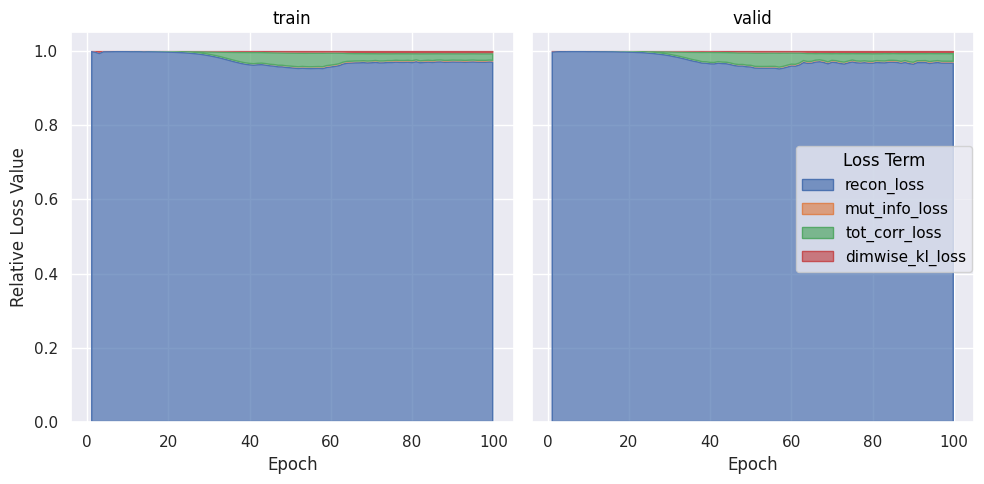

In [5]:

disent.visualizer.show_loss(plot_type="relative")

We can visualize our standard plots with `show_result`:


Creating plots ...


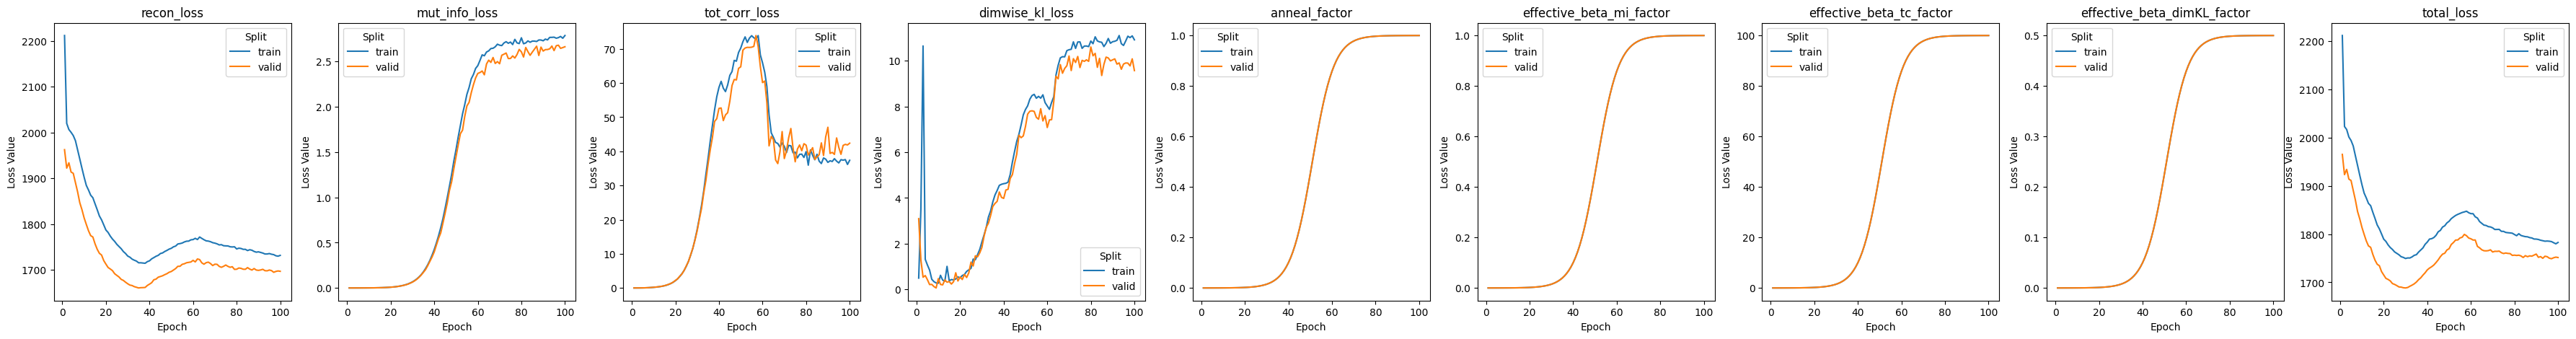

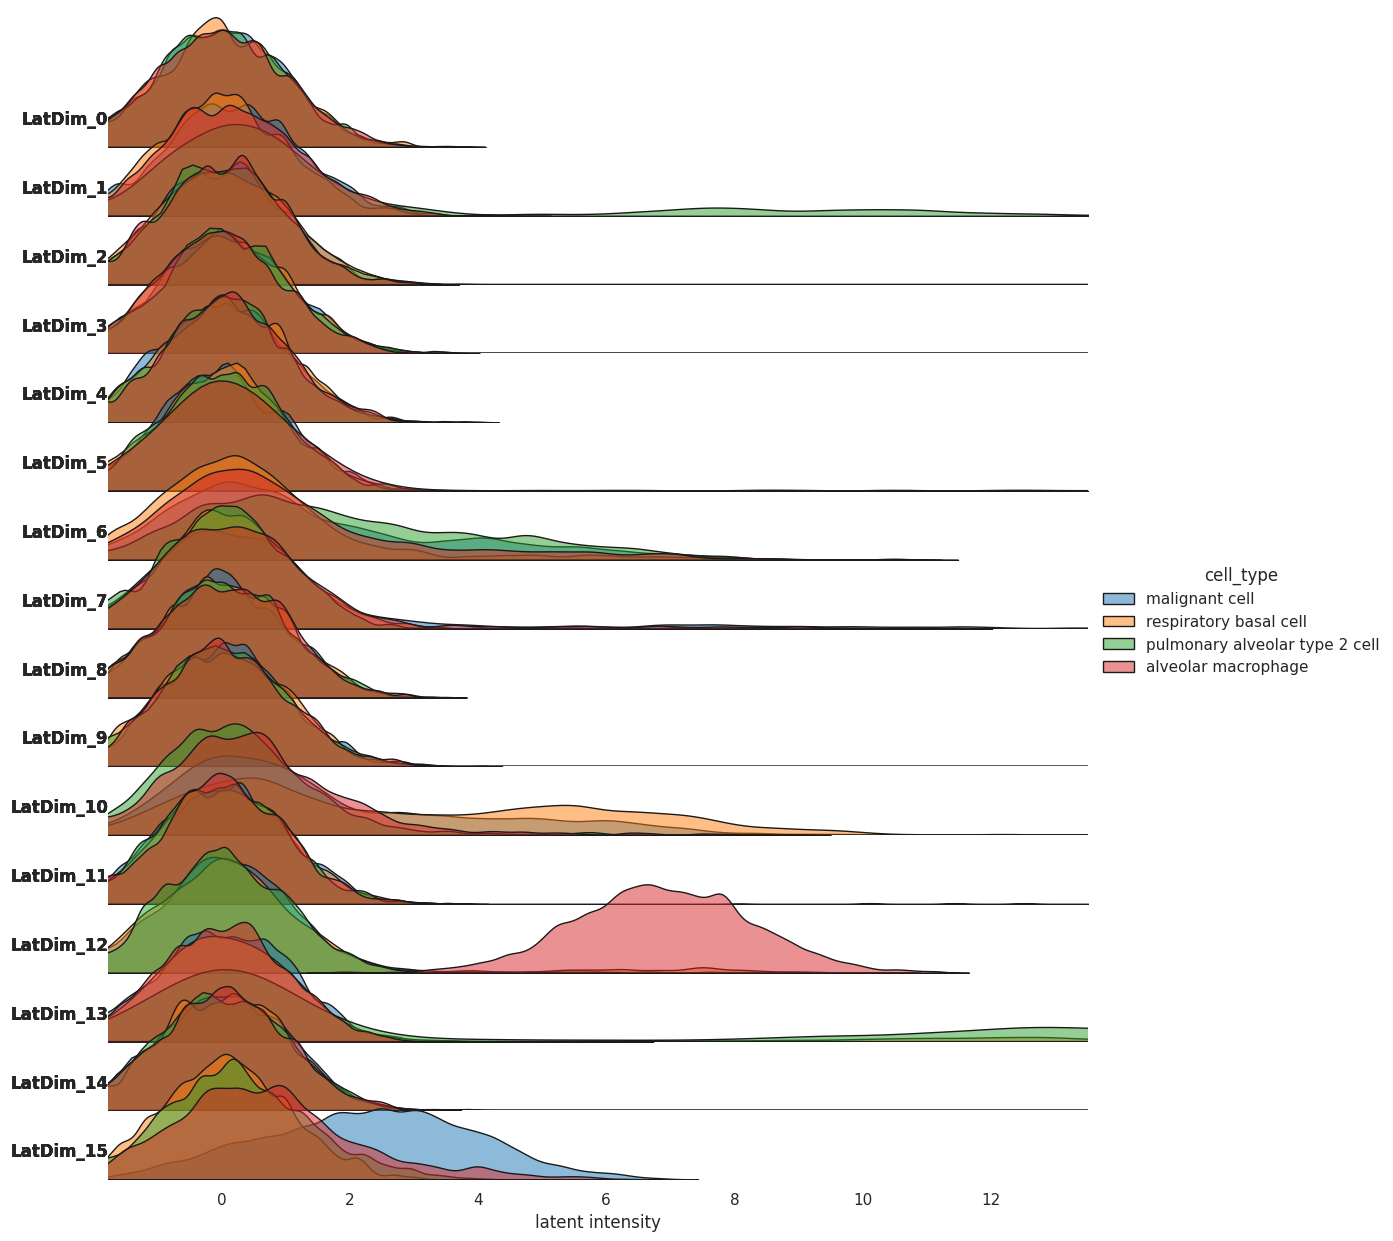

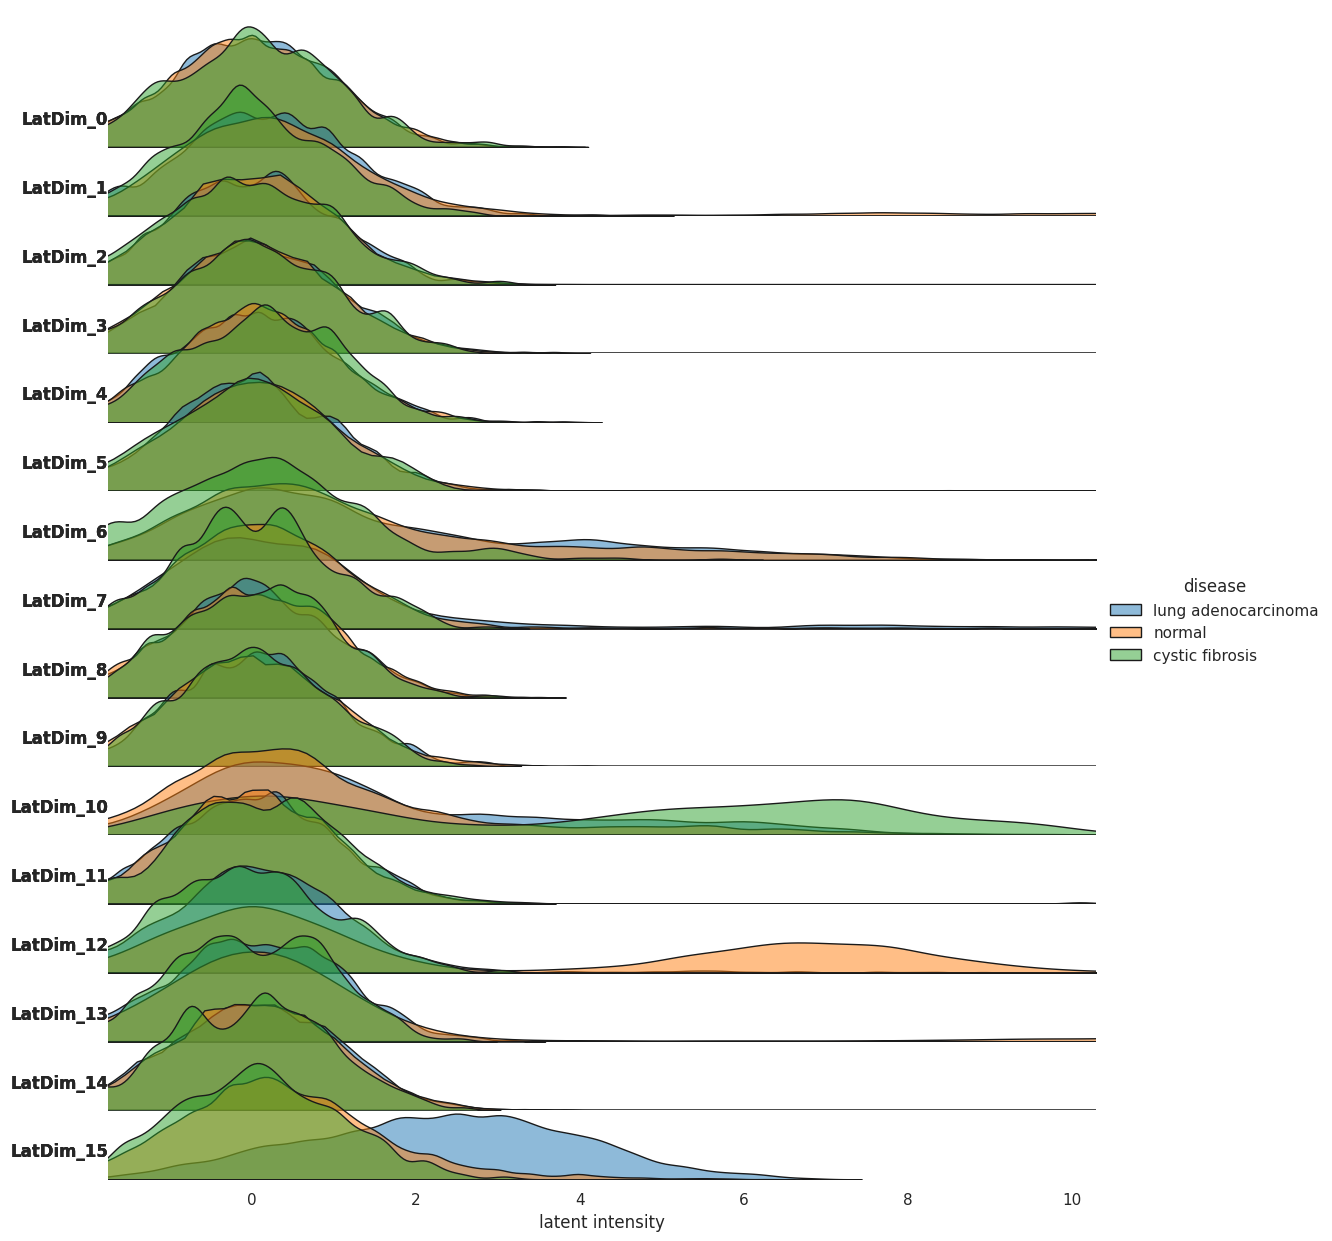

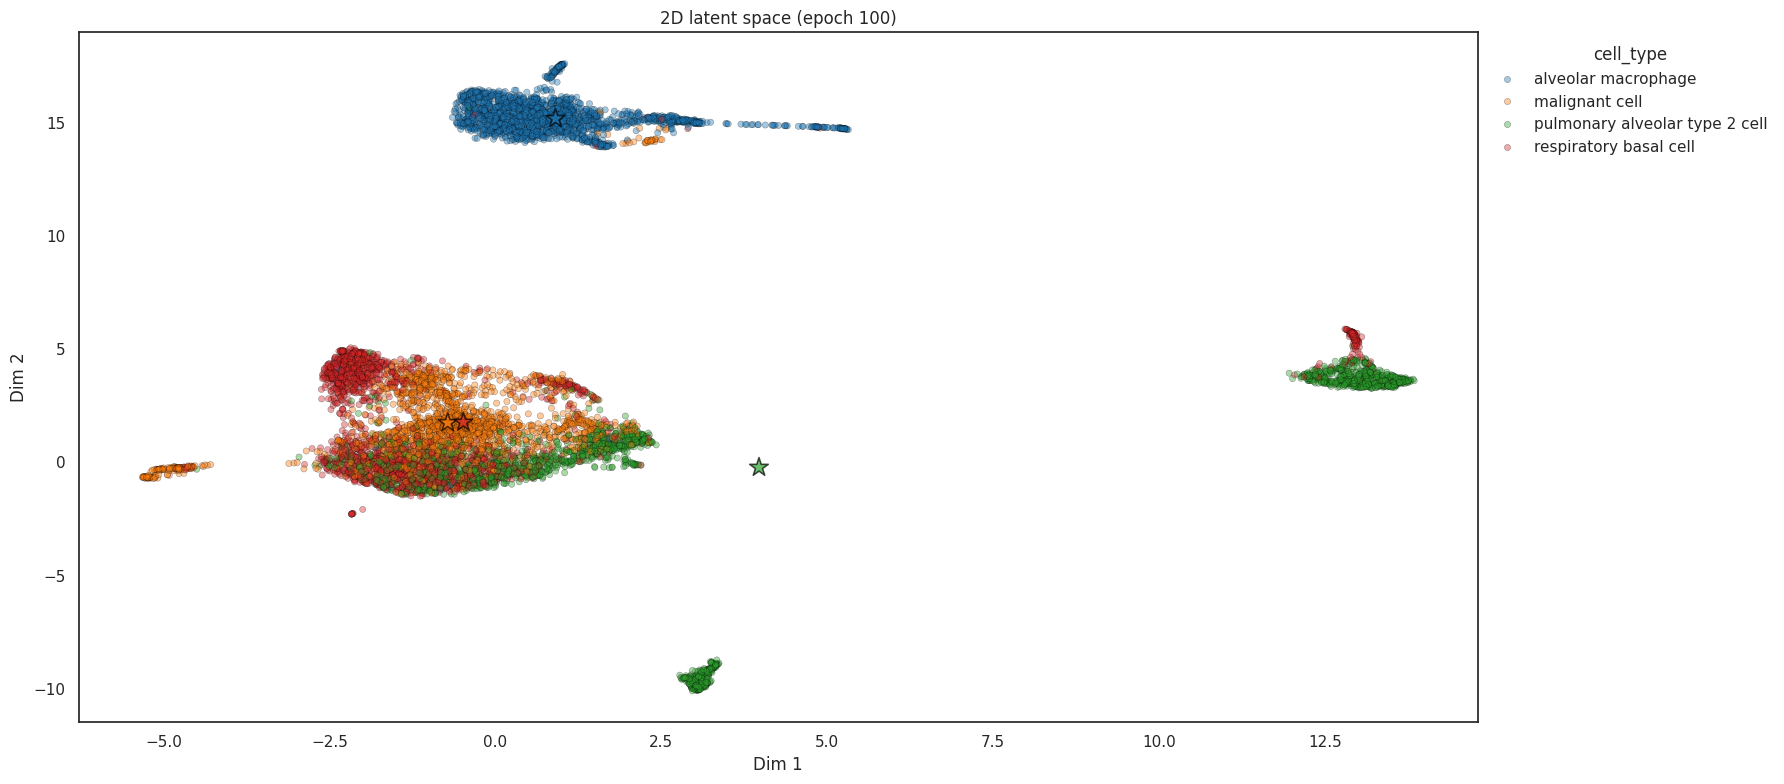

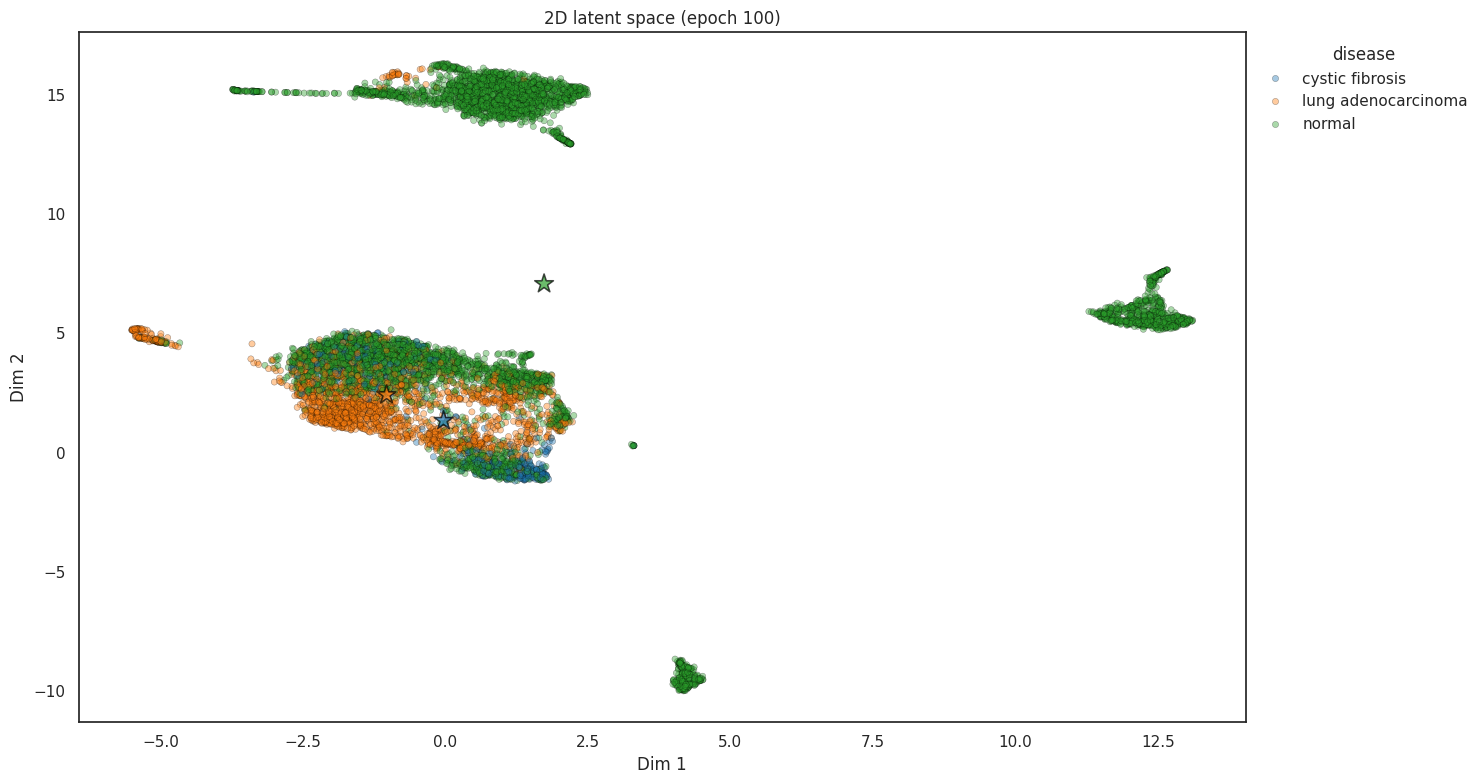

In [6]:

disent.show_result(params=["cell_type", "disease"])


#### 3.3) Save and Load Disentanglix

There are not `Disentanglix` specific steps here. See the `Getting Started - Vanillix` for details. Below is a basic save/load usecase:

In [7]:
import glob
import os
outpath = os.path.join("tutorial_res", "disent.pkl")
disent.save(file_path=outpath, save_all=True)

folder = os.path.dirname(outpath)
pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
model_files = glob.glob(os.path.join(folder, "*.pth"))

print("PKL files:", pkl_files)
print("Model files:", model_files)

# the load functionality automatically will build the pipeline object out of the three saved files
disent_loaded = acx.Disentanglix.load(outpath)

Preprocessor saved successfully.


Pipeline object saved successfully.
PKL files: ['tutorial_res/varix_preprocessor.pkl', 'tutorial_res/ontix.pkl', 'tutorial_res/maskix_preprocessor.pkl', 'tutorial_res/ontix_preprocessor.pkl', 'tutorial_res/disent.pkl', 'tutorial_res/disent_preprocessor.pkl']
Model files: ['tutorial_res/varix_model.pth', 'tutorial_res/disent_model.pth', 'tutorial_res/ontix_model.pth', 'tutorial_res/maskix_model.pth']
Attempting to load a pipeline from tutorial_res/disent.pkl...


Pipeline object loaded successfully. Actual type: Disentanglix
Preprocessor loaded successfully.


In [8]:
disent_loaded.predict(data=disent.result.datasets)


Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'mut_info_loss': TrainingDynamics(), 'tot_corr_loss': TrainingDynamics(), 'dimwise_kl_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_mi_factor': TrainingDynamics(), 'effective_beta_tc_factor': TrainingDynamics(), 'effective_beta_dimKL_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VarixArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=<autoencodix.data._numeric_dataset.NumericDataset object at 0x7bac2c29eec0>, valid=<autoencodix.data._numeric_dataset.NumericDataset object at 0x7bac2c29c340>, test=<autoencodix.data._numeric_dataset.NumericDataset object

Creating plots ...


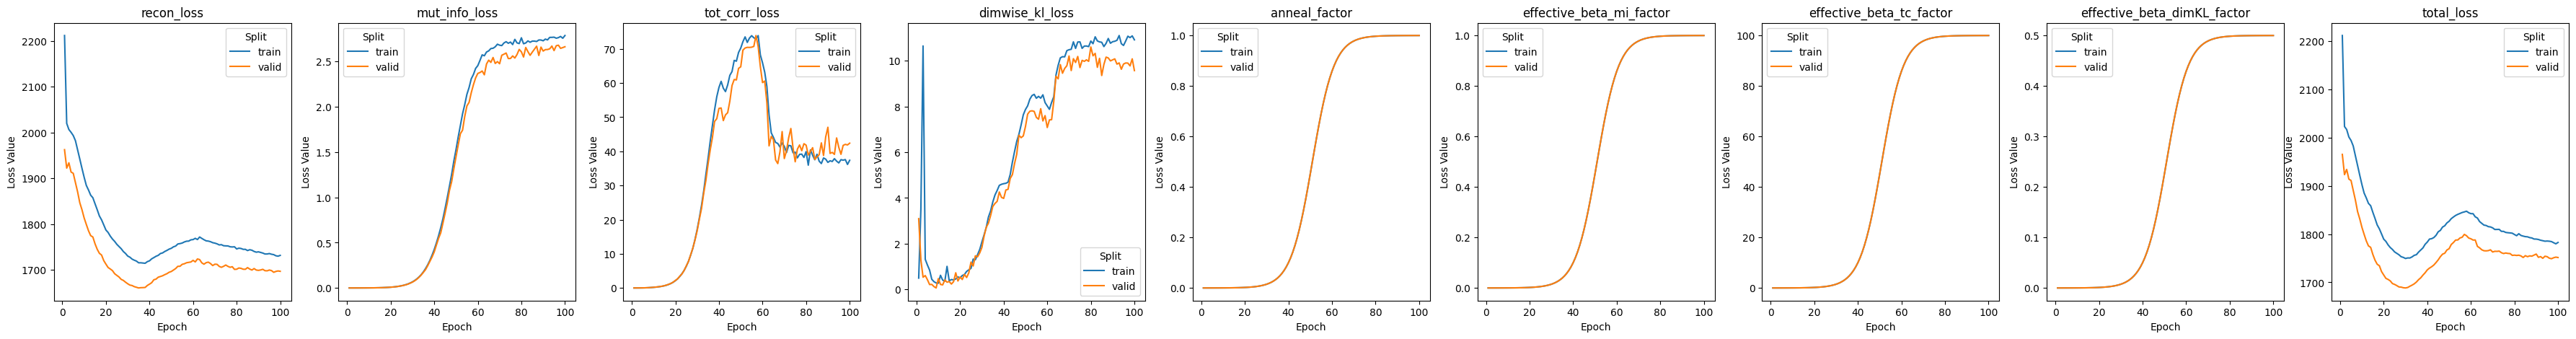

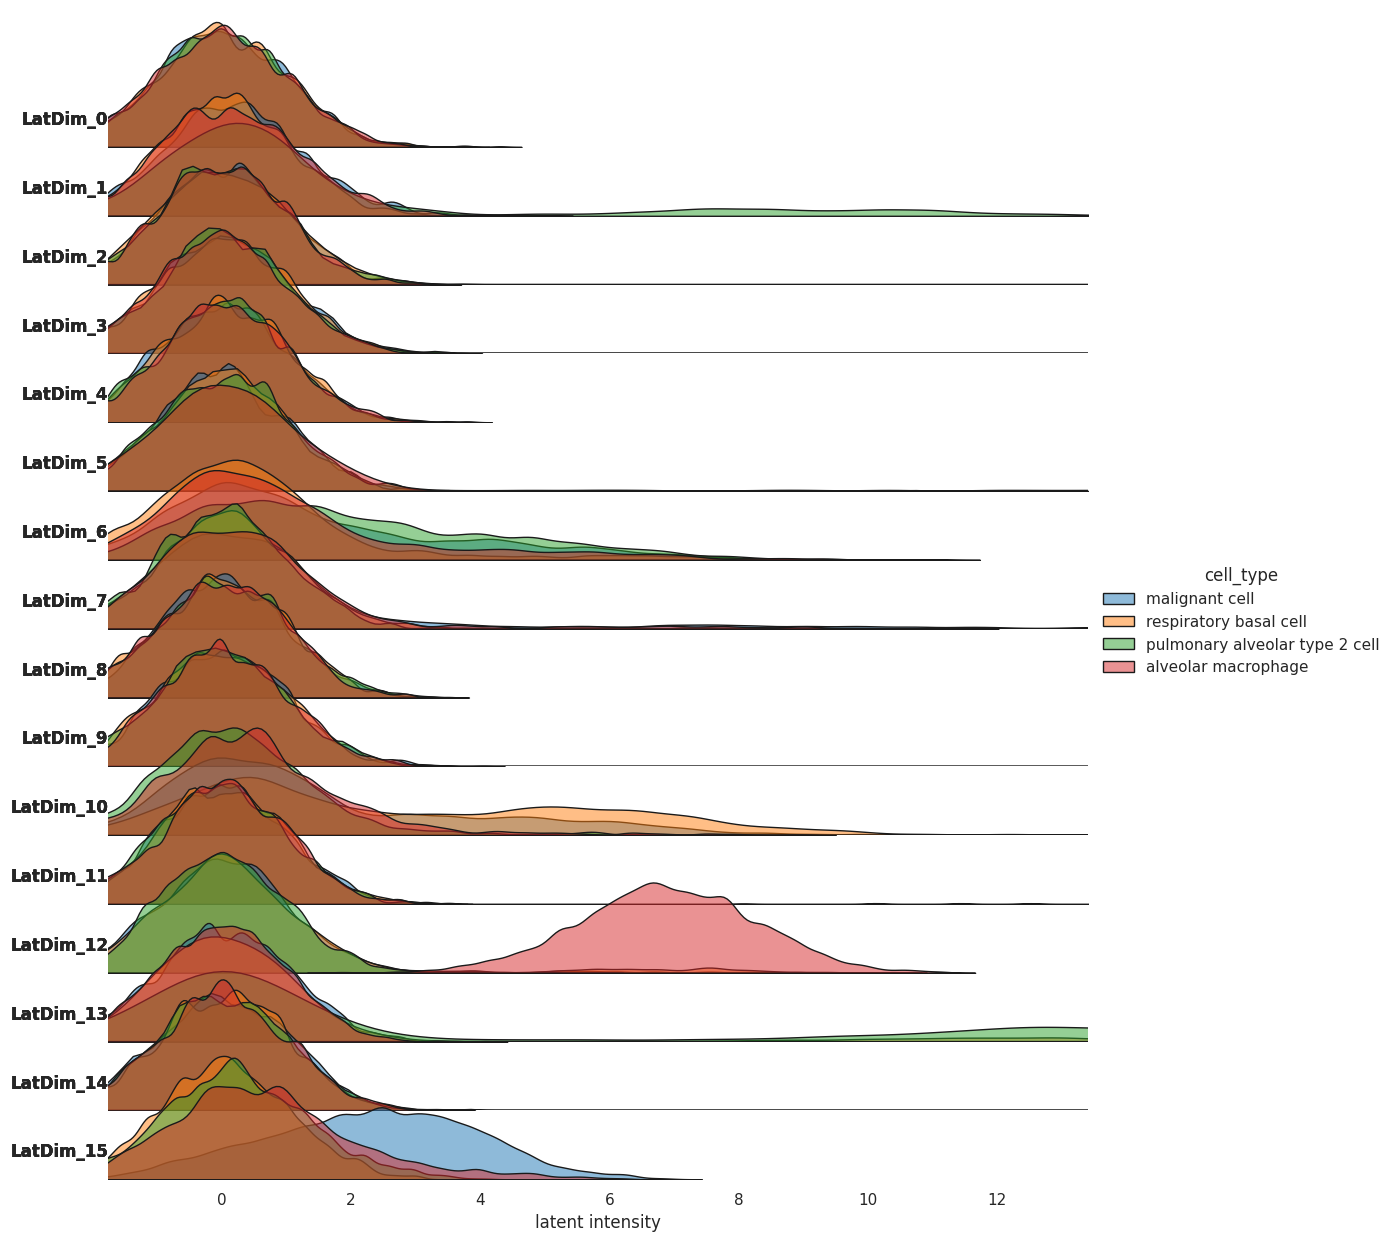

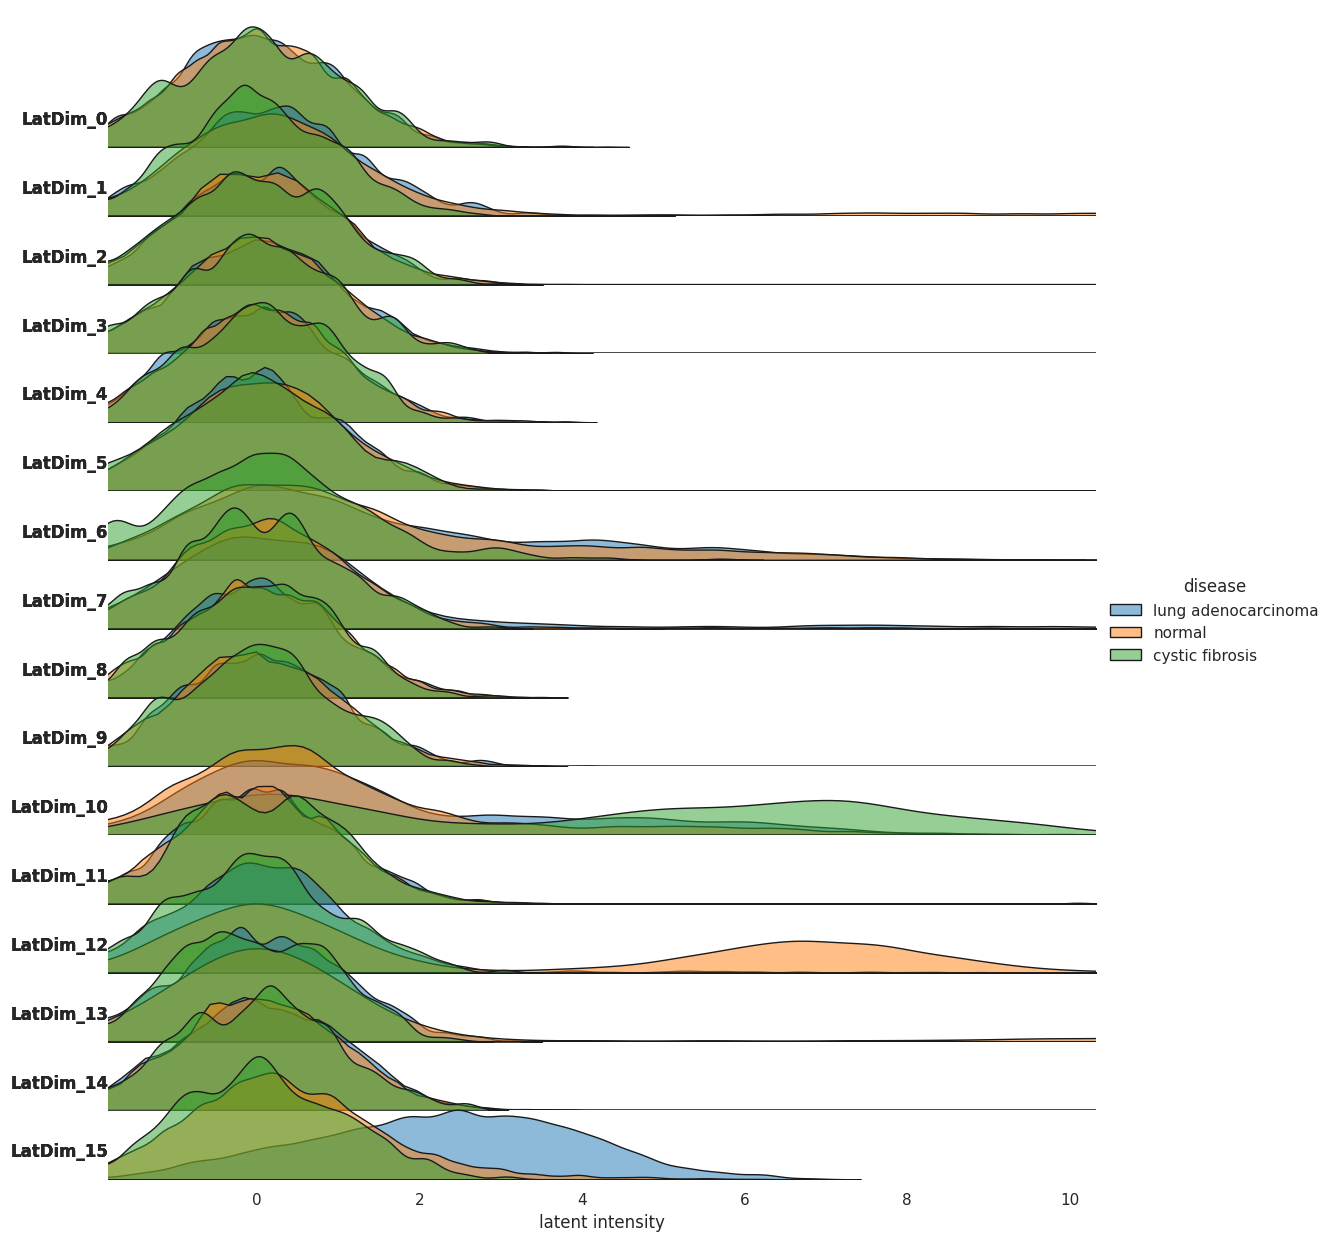

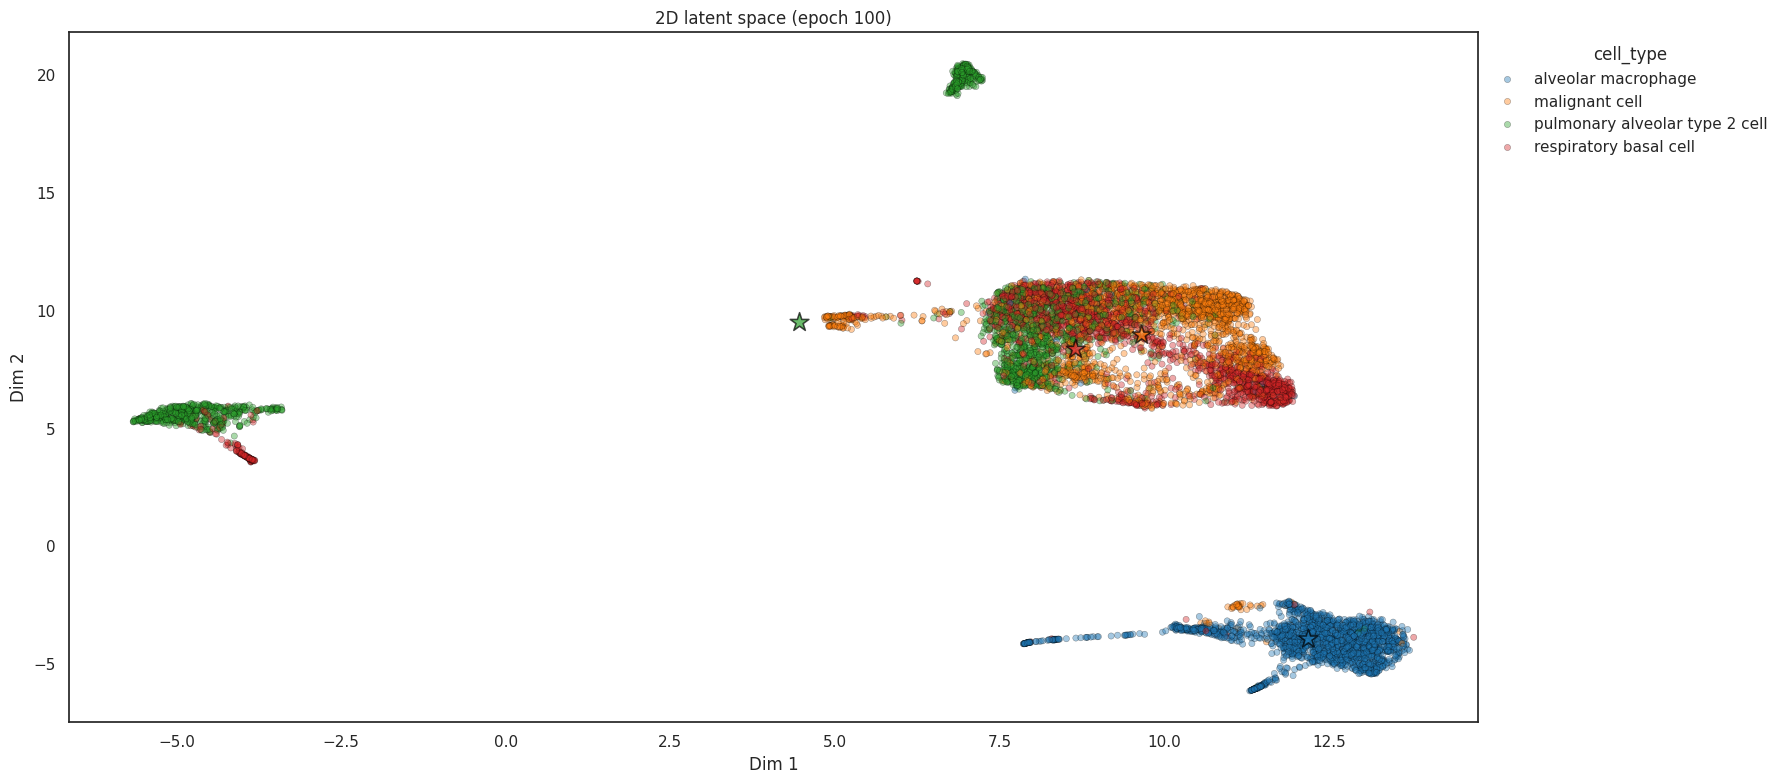

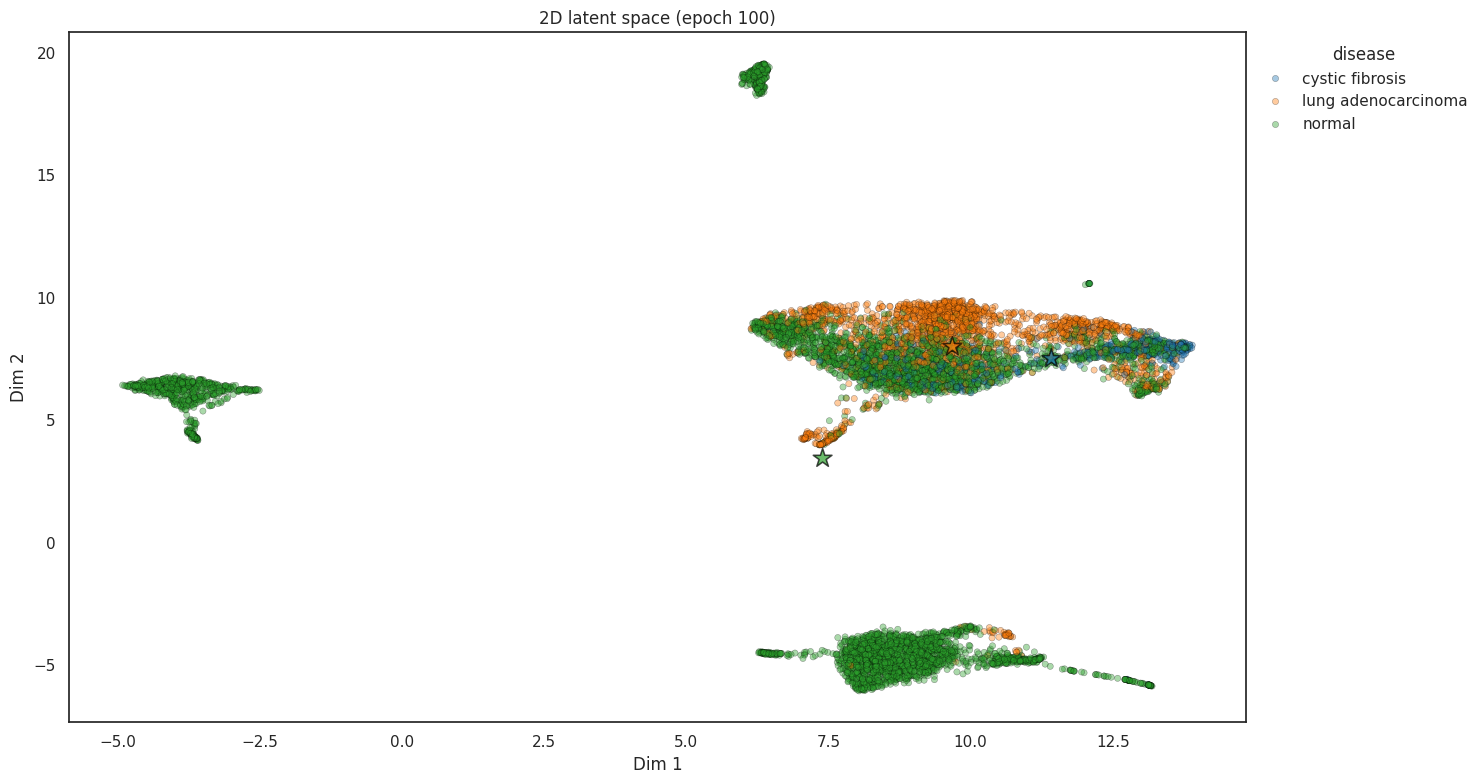

In [9]:

disent_loaded.show_result(params=["cell_type", "disease"])


#### Generate New Data
For a variational autoencoder, the generate or sample_latent_space step draws new latent vectors from the model’s learned latent distribution.

**Latent Sampling:** 
The model first aggregates the posterior over all encoded latent vectors in the chosen split and epoch by computing the mean (global_mu) and log-variance (global_logvar). It then samples new latent points from a diagonal Gaussian defined by these aggregate statistics, using the reparameterization trick to inject Gaussian noise.

**Number of Samples (n_samples):** 
Users can specify how many latent points to generate. The method expands the aggregated mean and log-variance to match the requested number of samples before sampling.

**Custom Latent Prior:** 
Optionally, a custom latent_prior can be provided (a tensor or NumPy array with shape (n_samples, latent_dim)), which will be used directly instead of the aggregated posterior. This is basically the `decode` step.


In [10]:
reconstructions_generated = disent_loaded.generate(n_samples=5)
print(reconstructions_generated.shape)

torch.Size([5, 2000])
